The following project is based on a classification problem which involves loan approval prediction. The dataset used in the project was extracted from Kaggle: https://www.kaggle.com/datasets/udaymalviya/bank-loan-data/data.

However for every step and code in the project that is not referenced was done independently and I take full responsibility of ownership. 

The dataset contains about 45000 obverations of loan applicants and various features or attributes which includes; age, gender, level of education, loan amount and so on with that target attribute as loan status which shows 1 if the loan was approved and 0 if not approved.

This we will explore in our Exploratory Data Analysis Section. We also to preprocess our dataset were necesssary to get it ready for modelling.

In the project we have apply two classiffication algorithms using python.

In [1]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
#Loading dataset
df = pd.read_csv('loan_data.csv')

#### Exploratory Data Analysis

In [4]:
# Viewing the dataset
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [5]:
#Summary of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [6]:
#Data Shape
df.shape

(45000, 14)

In [7]:
# statistical summary of the numerical columns
df.describe(include = 'all')

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
count,45000.000000,45000,45000,4.500000e+04,45000.000000,45000,45000.000000,45000,45000.000000,45000.000000,45000.000000,45000.000000,45000,45000.000000
unique,NaN,2,5,NaN,NaN,4,NaN,6,NaN,NaN,NaN,NaN,2,NaN
top,NaN,male,Bachelor,NaN,NaN,RENT,NaN,EDUCATION,NaN,NaN,NaN,NaN,Yes,NaN
freq,NaN,24841,13399,NaN,NaN,23443,NaN,9153,NaN,NaN,NaN,NaN,22858,NaN
mean,27.764178,NaN,NaN,8.031905e+04,5.410333,NaN,9583.157556,NaN,11.006606,0.139725,5.867489,632.608756,NaN,0.222222
std,6.045108,NaN,NaN,8.042250e+04,6.063532,NaN,6314.886691,NaN,2.978808,0.087212,3.879702,50.435865,NaN,0.415744
min,20.000000,NaN,NaN,8.000000e+03,0.000000,NaN,500.000000,NaN,5.420000,0.000000,2.000000,390.000000,NaN,0.000000
25%,24.000000,NaN,NaN,4.720400e+04,1.000000,NaN,5000.000000,NaN,8.590000,0.070000,3.000000,601.000000,NaN,0.000000
50%,26.000000,NaN,NaN,6.704800e+04,4.000000,NaN,8000.000000,NaN,11.010000,0.120000,4.000000,640.000000,NaN,0.000000
75%,30.000000,NaN,NaN,9.578925e+04,8.000000,NaN,12237.250000,NaN,12.990000,0.190000,8.000000,670.000000,NaN,0.000000


In [8]:
# Checking for missing values
df.isna().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [9]:
#Checking for duplicates
df.duplicated().sum()

np.int64(0)

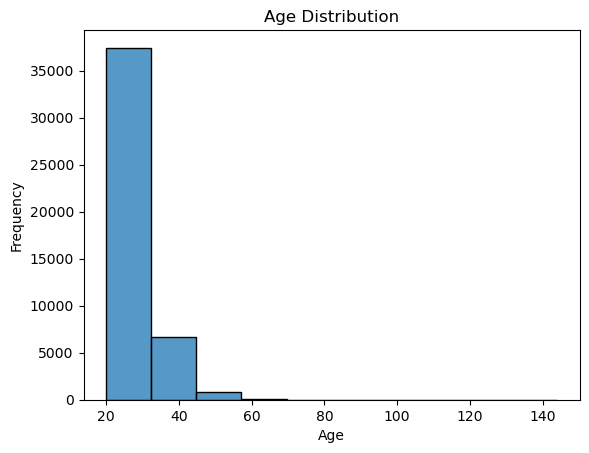

In [10]:
# Viewing the distribution of Age
sns.histplot(data=df, x='person_age', bins=10)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

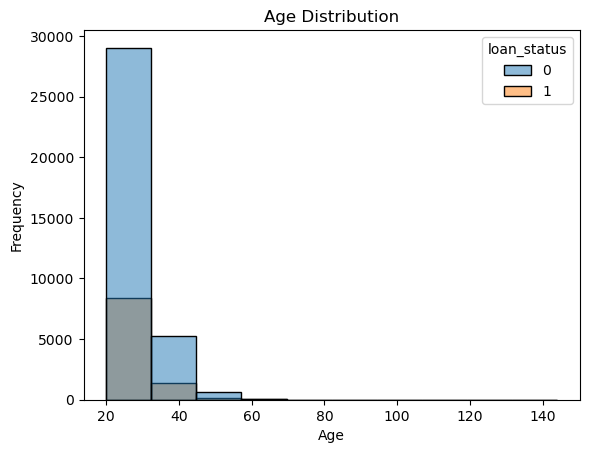

In [11]:
# Viewing the distribution of Age and the loan_status
sns.histplot(data=df, x='person_age', hue='loan_status', bins=10)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

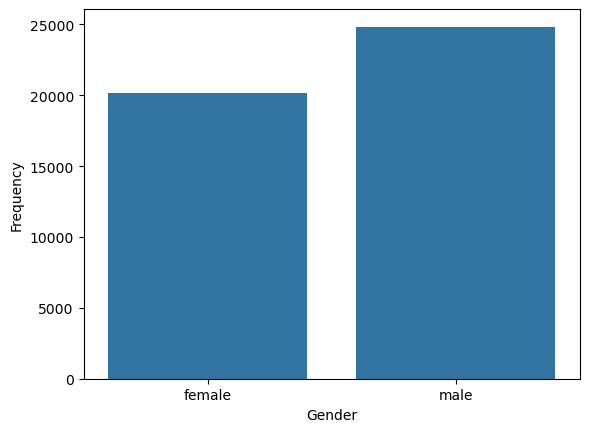

person_gender
male      24841
female    20159
Name: count, dtype: int64


In [12]:
#Viewing the gender counts
sns.countplot(data=df, x='person_gender')
plt.xlabel('Gender')
plt.ylabel('Frequency')
plt.show()

print(df['person_gender'].value_counts())

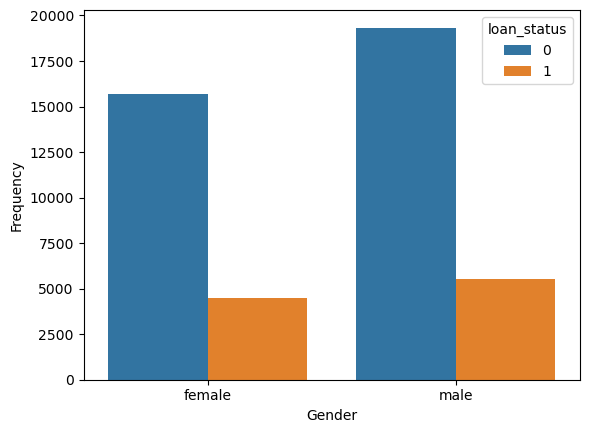

In [13]:
sns.countplot(data=df, x='person_gender', hue = 'loan_status')
plt.xlabel('Gender')
plt.ylabel('Frequency')
plt.show()

In [14]:
#Viewing the intent for loan
df['loan_intent'].value_counts().sort_values()

loan_intent
HOMEIMPROVEMENT      4783
DEBTCONSOLIDATION    7145
PERSONAL             7552
VENTURE              7819
MEDICAL              8548
EDUCATION            9153
Name: count, dtype: int64

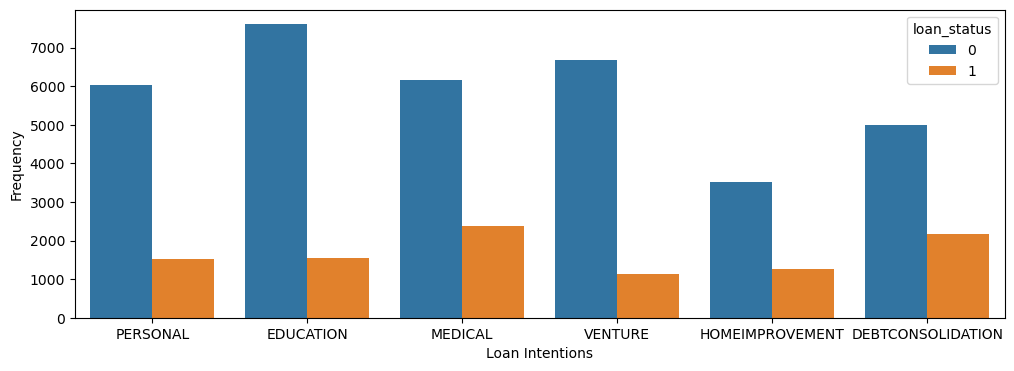

In [15]:
# Viewing the Count of the intent and loan status
plt.figure(figsize=(12, 4))
sns.countplot(data=df, x='loan_intent', hue ='loan_status')
plt.xlabel('Loan Intentions')
plt.ylabel('Frequency')
plt.show()

The percentage gives us a better understanding, showing the rate of approval based on the intent, with 'Debt Consolidations' having the most approval rate of 30%, followed by medical purposes with ~28% with the rest making up the number.

In [16]:
pct_approved = df[df['loan_status'] == 1].groupby('loan_intent').size()/(df.groupby('loan_intent').size())*100
pct_approved = pct_approved.round(1)
#.astype(str) + '%'
pct_approved.sort_values(ascending=False)

loan_intent
DEBTCONSOLIDATION    30.3
MEDICAL              27.8
HOMEIMPROVEMENT      26.3
PERSONAL             20.1
EDUCATION            17.0
VENTURE              14.4
dtype: float64

In [17]:
# previous loan default percentage table
default_per = pd.crosstab(df['previous_loan_defaults_on_file'], df['loan_status'], normalize='index') * 100
default_per

loan_status,0,1
previous_loan_defaults_on_file,,
No,54.836961,45.163039
Yes,100.000000,0.000000


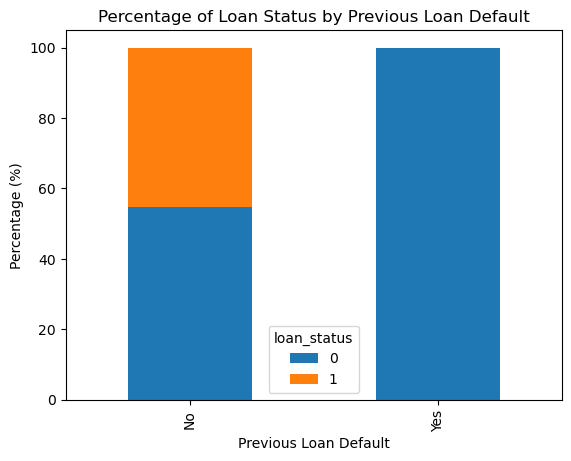

loan_status                          0      1
previous_loan_defaults_on_file               
No                               54.84  45.16
Yes                             100.00   0.00


In [18]:
# plotting in a bar chart
default_per.plot(kind='bar', stacked=True)
plt.title('Percentage of Loan Status by Previous Loan Default')
plt.xlabel('Previous Loan Default')
plt.ylabel('Percentage (%)')
plt.show()
print(default_per.round(2))

Using the stacked bar plot while comparing the relationship of 'previous loan default on file' feature with our target variable. As we clearly observed that previous loan default have no chance for loan approval which is logically correct, this explain better when people default on previous loans they tends not to be eligible for approval. This feature play a significant role in our target variable (loan_status) which also shows that people with clean record or past defaults are more likely to get approval.

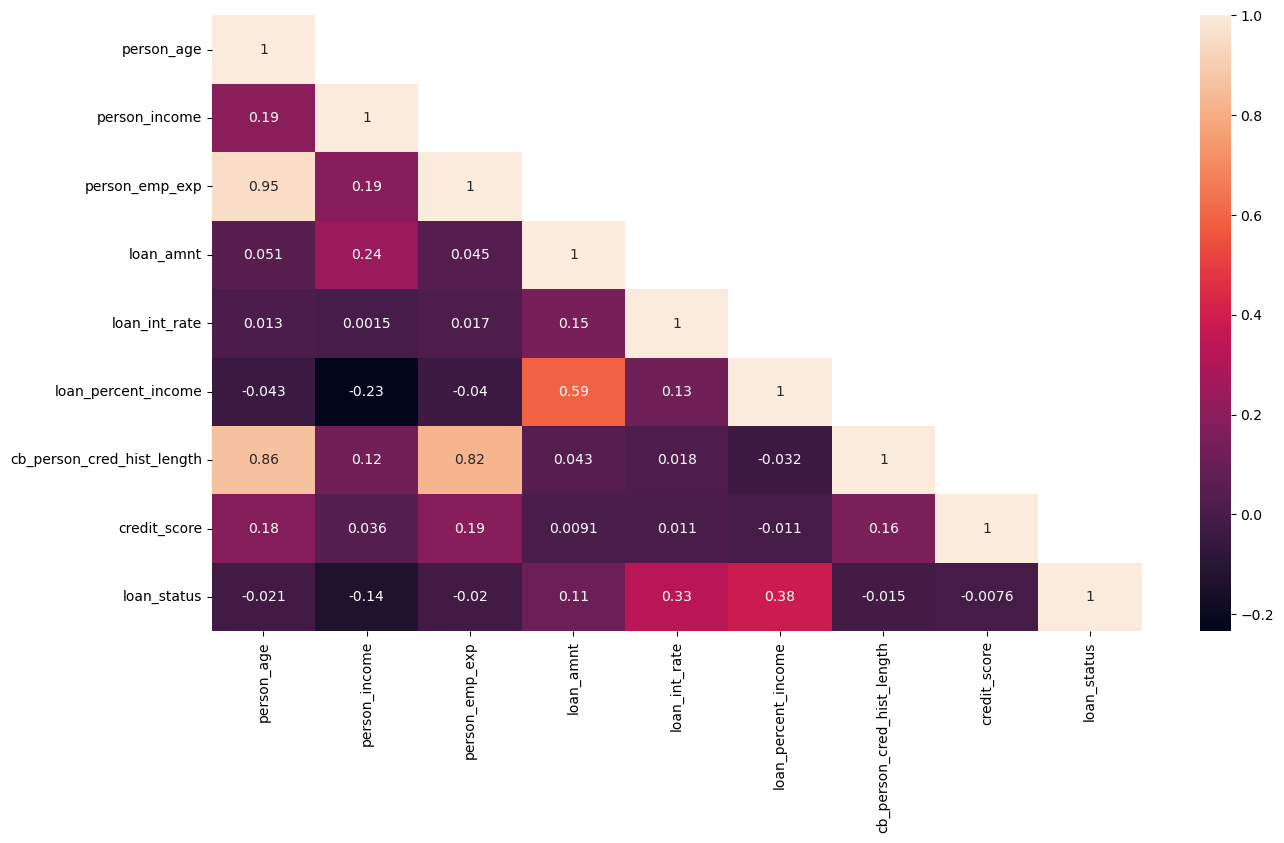

In [19]:
# Plotting the Correlation Matrix

num_var = df.select_dtypes(include = ['float64', 'int'])
corr_mat = num_var.corr()

low_tri = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
plt.figure(figsize=(15, 8))
sns.heatmap(data=corr_mat, annot=True, square=False, mask=low_tri)
plt.show()


Interpretation of the Correlation Matrix
This correlation matrix displays the strength and direction of relationships between the numerical variables in the dataset. The values range from -1 to +1:

+1 indicates a perfect positive relationship

-1 indicates a perfect negative relationship

0 means no linear relationship

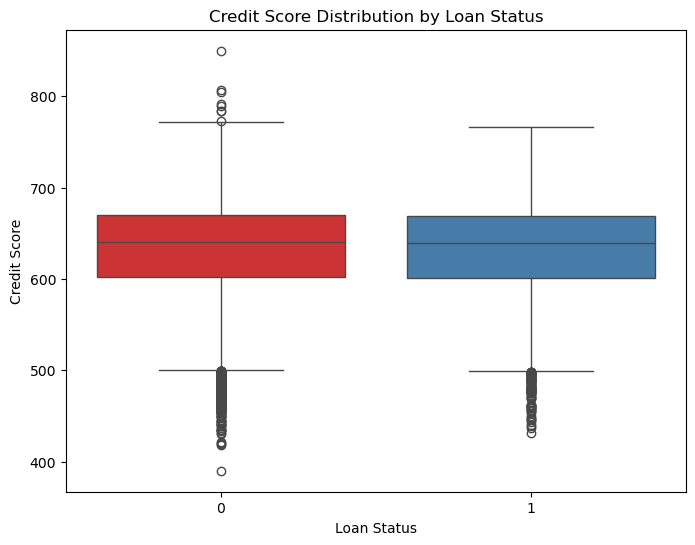

In [20]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='loan_status', y='credit_score', palette='Set1')
plt.title('Credit Score Distribution by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Credit Score')
plt.show()

In [21]:
df['loan_status'].value_counts()

loan_status
0    35000
1    10000
Name: count, dtype: int64

From the visualization of the boxplot of our loan_status we can see that this looks more confusing and doesn't seem to have a significant explanation of the relationship of the credit_score to the loan staus. This can be as a result of having an imbalance dataset which may affect the distribution. The value_counts of our loan_status confirms the imbalance between our approved and not approved. For a this project we use the SMOTE method which is one of the reliable method of balancing data. The SMOTE avoid duplicating the data, it generates synthetic samples for the minority class while also avoiding overfitting.

### Feature Selection and Modelling

For the application of the SMOTE method; this requires all features in a dataset to be numerical. In the Preparation of our dataset for training, knowing that Machine Learning models understand only numeric values, we must convert the categorical values into numeric format. Our data contains some columns with categorical data like the person_gender and previous_loan_defaults_on_file which we have easily replaced with values of 0 and 1, because the have only 2 categorically values or boolean values. However, in the case of the person_education, personal_home_ownership and loan_intent, these are categorical data with more than 3 values in the columns with no ranks or order. To achieve this we introduce the One-Hot Encoding which is a method for converting categorical variables into a numerical format without introducing unintended relationships.

##### What is one-hot encoding?

One-hot encoding is a data encoding technique used to convert categorical features of a dataset into numeric features. If a categorical feature has N unique values, we create N new binary columns in the dataset for one-hot encoding. Each new column represents a unique value in the existing categorical feature. If the existing categorical column contains the value represented by a new column, the value in the new column is set to 1. Values in the rest of the new columns are set to 0. [1]

In [22]:
# Replacing the categorical value of gender and previous loan default to 0 and 1
df['person_gender'] = df['person_gender'].replace(['male', 'female'], [0,1])
df['previous_loan_defaults_on_file'] = df['previous_loan_defaults_on_file'].replace(['No', 'Yes'], [0,1])

In [23]:
# Converting to numerical using OneHotEncoder 
df = pd.get_dummies(df, columns=['person_home_ownership', 'loan_intent'], dtype=int, drop_first=True)

In [24]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_cat = ['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']
# Create the encoder
enc = OrdinalEncoder(categories=[ordinal_cat])

# Applying it
df[['person_education']] = enc.fit_transform(df[['person_education']])

In [25]:
#Viewing the dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  int64  
 2   person_education                45000 non-null  float64
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   loan_amnt                       45000 non-null  float64
 6   loan_int_rate                   45000 non-null  float64
 7   loan_percent_income             45000 non-null  float64
 8   cb_person_cred_hist_length      45000 non-null  float64
 9   credit_score                    45000 non-null  int64  
 10  previous_loan_defaults_on_file  45000 non-null  int64  
 11  loan_status                     45000 non-null  int64  
 12  person_home_ownership_OTHER     

In [26]:
# Importing SMOTE
from imblearn.over_sampling import SMOTE


# Splitting and Balancing the dataset
X = df.drop('loan_status', axis=1)
y = df['loan_status']

sm = SMOTE(random_state=42)
X_bal, y_bal = sm.fit_resample(X, y)

#Concatenating the dataset 
df = pd.concat([X_bal, y_bal], axis=1)

df['loan_status'].value_counts()

  File "c:\Users\Elpro\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Elpro\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Elpro\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Elpro\anaconda3\Lib\subprocess.

loan_status
1    35000
0    35000
Name: count, dtype: int64

As stated this project is based on a classification problem where the objective is to classify and to predict if a loan application would be approved or not. We have simply explored our dataset and preprocess it for training, will employ scikit-learn library for classification. We will apply two different classification algorithms, (i.e) KNN and the Logistic regression.

firstly, determining the target Variable and the independent variable and spliting our data into X - independent and y - dependent features


In [27]:
# Splitting the data
X = df.drop('loan_status', axis=1)
y = df['loan_status']

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [29]:
from sklearn.preprocessing import StandardScaler

# Select non binary columns
cont_cols = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'credit_score', 
             'loan_percent_income', 'loan_int_rate', 'cb_person_cred_hist_length']

# Copying the data
sc = StandardScaler()
X_train_sc = X_train.copy()
X_test_sc = X_test.copy()

# Scaling and Transforming 
X_train_sc[cont_cols] = sc.fit_transform(X_train[cont_cols])
X_test_sc[cont_cols] = sc.transform(X_test[cont_cols])

#### Training

#### K-Nearest Neighbor

In [30]:
#Importing KNN and applying model on our training set
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
classifier.fit(X_train_sc, y_train)

KNeighborsClassifier()

In [31]:
y_pred = classifier.predict(X_test_sc)
print(y_pred)

[0 1 0 ... 0 1 1]


In [32]:
#Evaluating Prediction
from sklearn import metrics
acc = metrics.accuracy_score(y_test,y_pred)
print('accuracy:', round(acc, 2))
cm = metrics.confusion_matrix(y_test,y_pred)
print('confusion matrix:')
print(cm,'\n\n')
result = metrics.classification_report(y_test,y_pred)
print('Classification Report:\n')
print(result)

accuracy: 0.91
confusion matrix:
[[6071  952]
 [ 371 6606]] 


Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.86      0.90      7023
           1       0.87      0.95      0.91      6977

    accuracy                           0.91     14000
   macro avg       0.91      0.91      0.91     14000
weighted avg       0.91      0.91      0.91     14000



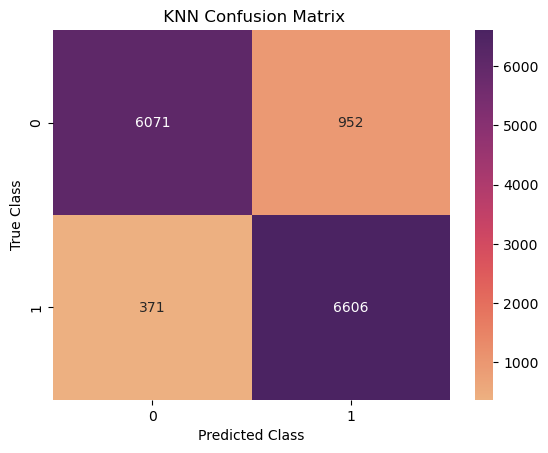

In [33]:
ax = sns.heatmap(cm, cmap='flare', annot=True, fmt='d')
plt.xlabel('Predicted Class', fontsize=10)
plt.ylabel('True Class', fontsize=10)
plt.title(' KNN Confusion Matrix', fontsize=12)
plt.show()

#### Logistic Regression

In [34]:
from sklearn.linear_model import LogisticRegression

In [35]:
#Training the model
logr = LogisticRegression()
logr.fit(X_train_sc, y_train)

#Predict on the test data
y_pred = logr.predict(X_test_sc)

In [36]:
#Evaluate accuracy
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc*100:.2f}%")
cfm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 90.67%

Confusion Matrix:
[[6071  952]
 [ 371 6606]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.88      0.90      7023
           1       0.89      0.93      0.91      6977

    accuracy                           0.91     14000
   macro avg       0.91      0.91      0.91     14000
weighted avg       0.91      0.91      0.91     14000



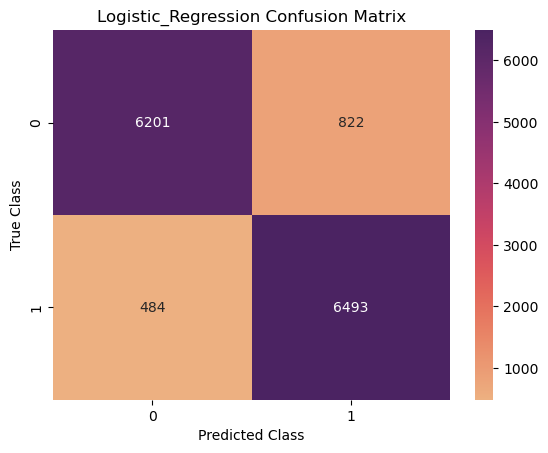

In [37]:
ax = sns.heatmap(cfm, cmap='flare', annot=True, fmt='d')
plt.xlabel('Predicted Class', fontsize=10)
plt.ylabel('True Class', fontsize=10)
plt.title('Logistic_Regression Confusion Matrix', fontsize=12)
plt.show()